# SVM – Support Vector Machine

In [4]:
import math
import random
import csv
import numpy as np                # apenas para operações matriciais (kernel)
import matplotlib.pyplot as plt
from collections import Counter


In [5]:
LABEL_MAP = {
    'Tem jogo'         : 0,
    'Possibilidade_fim': 1,
    'Empate'           : 2,
    'Fim_O_Vence'      : 3,
    'Fim_X_Vence'      : 4
}
LABEL_NAMES  = ['Tem jogo', 'Possibilidade_fim', 'Empate', 'Fim_O_Vence', 'Fim_X_Vence']
NOMES_CURTOS = ['Tem jogo', 'Poss. Fim', 'Empate', 'O Vence', 'X Vence']
N_CLASSES    = 5

def carrega_dataset(caminho):
    """Lê o CSV e retorna arrays numpy (X, y)."""
    X_lista, y_lista = [], []
    with open(caminho) as f:
        for linha in csv.reader(f):
            X_lista.append([float(v) for v in linha[:9]])
            y_lista.append(LABEL_MAP[linha[9]])
    return np.array(X_lista), np.array(y_lista)

X_treino, y_treino = carrega_dataset('/content/sample_data/dataset_treino.csv')
X_teste,  y_teste  = carrega_dataset('/content/sample_data/dataset_testes.csv')

print('=== Amostras por classe – Treino ===')
for i, nome in enumerate(LABEL_NAMES):
    print(f'  {nome}: {int((y_treino == i).sum())}')

print(f'\nTotal treino : {len(X_treino)}')
print(f'Total teste  : {len(X_teste)}')
print(f'\nExemplo de entrada : {X_treino[0]}')
print(f'Rótulo correspondente: {LABEL_NAMES[y_treino[0]]}')


=== Amostras por classe – Treino ===
  Tem jogo: 180
  Possibilidade_fim: 180
  Empate: 166
  Fim_O_Vence: 180
  Fim_X_Vence: 180

Total treino : 886
Total teste  : 98

Exemplo de entrada : [ 1.  1. -1. -1. -1.  1.  1. -1.  1.]
Rótulo correspondente: Empate


In [6]:
def calcula_matriz_kernel_rbf(X, gamma=0.5):
    """
    Calcula a matriz de kernel RBF K[i,j] = exp(-gamma * ||x_i - x_j||^2)
    para todas as combinações de amostras em X.

    Usa a identidade matricial para eficiência:
    ||xi - xj||^2 = ||xi||^2 + ||xj||^2 - 2*xi.xj

    Retorna:
        K – matriz (n x n) com valores entre 0 e 1
    """
    normas_quad = np.sum(X ** 2, axis=1)           # ||xi||^2 para cada i
    dist2 = (normas_quad[:, None]                   # (n,1)
           + normas_quad[None, :]                   # (1,n)
           - 2.0 * (X @ X.T))                       # produto matricial
    dist2 = np.maximum(dist2, 0.0)                  # evita erros numéricos
    return np.exp(-gamma * dist2)

def kernel_rbf_par(x1, x2, gamma=0.5):
    """Kernel RBF para um único par de amostras."""
    dist2 = np.sum((np.array(x1) - np.array(x2)) ** 2)
    return math.exp(-gamma * dist2)

# Demonstração
x_A = np.array([ 1.,  1., -1., -1., -1.,  1.,  1., -1.,  1.])
x_B = np.array([ 1., -1.,  1., -1., -1.,  1.,  0.,  0.,  1.])
x_C = np.array([ 0.,  0.,  0.,  0., -1.,  0.,  1., -1.,  1.])
print(f'K(A, A) = {kernel_rbf_par(x_A, x_A):.4f}  (amostras idênticas → K = 1)')
print(f'K(A, B) = {kernel_rbf_par(x_A, x_B, 0.5):.4f}  (amostras similares)')
print(f'K(A, C) = {kernel_rbf_par(x_A, x_C, 0.5):.4f}  (amostras diferentes)')

K_demo = calcula_matriz_kernel_rbf(np.array([x_A, x_B, x_C]), gamma=0.5)
print(f'\nMatriz kernel 3x3 (amostras A, B, C):')
print(np.round(K_demo, 4))


K(A, A) = 1.0000  (amostras idênticas → K = 1)
K(A, B) = 0.0067  (amostras similares)
K(A, C) = 0.0821  (amostras diferentes)

Matriz kernel 3x3 (amostras A, B, C):
[[1.     0.0067 0.0821]
 [0.0067 1.     0.0302]
 [0.0821 0.0302 1.    ]]


In [7]:
def treina_svm_smo(X, y_bin, C=1.0, gamma=0.5, max_passes=10, tol=1e-3):
    """
    Treina um SVM binário com kernel RBF usando o algoritmo SMO.

    Parâmetros:
        X         – array (n, d) de amostras de treino
        y_bin     – array (n,) com rótulos +1 / -1
        C         – parâmetro de regularização (penalidade por violação de margem)
        gamma     – parâmetro do kernel RBF
        max_passes– máximo de passagens sem atualização (critério de parada)
        tol       – tolerância para verificar violação das condições KKT

    Retorna:
        alphas – multiplicadores de Lagrange (n,); alpha_i > 0 → vetor de suporte
        b      – bias escalar do hiperplano
    """
    n = len(X)
    alphas = np.zeros(n)           # multiplicadores de Lagrange
    b      = 0.0                   # bias

    # Pré-computar a matriz de kernel (economiza recálculo)
    K = calcula_matriz_kernel_rbf(X, gamma)

    passes = 0
    while passes < max_passes:
        num_mudancas = 0

        # Calcular scores f(xi) para todos os pontos de uma vez
        F = (alphas * y_bin) @ K + b    # shape (n,)

        for i in range(n):
            Ei = F[i] - y_bin[i]        # erro no ponto i

            # Verificar condição KKT: violação ocorre quando:
            # alpha_i < C e y_i * f(xi) < 1  →  precisa aumentar alpha_i
            # alpha_i > 0 e y_i * f(xi) > 1  →  precisa diminuir alpha_i
            violacao_kkt = (
                (y_bin[i] * Ei < -tol and alphas[i] < C) or
                (y_bin[i] * Ei >  tol and alphas[i] > 0)
            )
            if not violacao_kkt:
                continue

            # Escolher j aleatoriamente (diferente de i)
            j = random.randint(0, n - 1)
            while j == i:
                j = random.randint(0, n - 1)
            Ej = F[j] - y_bin[j]

            ai_old = alphas[i]
            aj_old = alphas[j]

            # ── Calcular limites L e H para alpha_j ────────────
            if y_bin[i] != y_bin[j]:
                L = max(0.0, alphas[j] - alphas[i])
                H = min(C,   C + alphas[j] - alphas[i])
            else:
                L = max(0.0, alphas[i] + alphas[j] - C)
                H = min(C,   alphas[i] + alphas[j])
            if L >= H:
                continue

            # ── Calcular eta (curvatura da função objetivo) ─────
            eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
            if eta >= 0:
                continue   # função objetivo não é convexa neste par

            # ── Atualizar alpha_j analiticamente ───────────────
            alphas[j] -= y_bin[j] * (Ei - Ej) / eta
            alphas[j]  = float(np.clip(alphas[j], L, H))
            if abs(alphas[j] - aj_old) < 1e-5:
                continue   # mudança insignificante

            # ── Atualizar alpha_i ───────────────────────────────
            alphas[i] += y_bin[i] * y_bin[j] * (aj_old - alphas[j])

            # ── Atualizar bias b ────────────────────────────────
            b1 = (b - Ei
                  - y_bin[i] * (alphas[i] - ai_old) * K[i, i]
                  - y_bin[j] * (alphas[j] - aj_old) * K[i, j])
            b2 = (b - Ej
                  - y_bin[i] * (alphas[i] - ai_old) * K[i, j]
                  - y_bin[j] * (alphas[j] - aj_old) * K[j, j])
            if   0 < alphas[i] < C: b = b1
            elif 0 < alphas[j] < C: b = b2
            else:                   b = (b1 + b2) / 2.0

            # Recalcular F após atualização
            F = (alphas * y_bin) @ K + b
            num_mudancas += 1

        # Critério de parada: nenhuma atualização → incrementar passes
        passes = passes + 1 if num_mudancas == 0 else 0

    return alphas, b

print('Função treina_svm_smo definida com sucesso.')


Função treina_svm_smo definida com sucesso.


In [8]:
def calcula_scores(X_sv, y_sv, alphas, b, X_novo, gamma=0.5):
    """
    Calcula os scores f(x) para múltiplas amostras novas.

    f(x) = sum_{i: alpha_i > 0} alpha_i * y_i * K(x_i, x) + b

    Parâmetros:
        X_sv   – amostras de treino usadas no treinamento (n_sv, d)
        y_sv   – rótulos ±1 das amostras de treino
        alphas – multiplicadores de Lagrange treinados
        b      – bias treinado
        X_novo – novas amostras a classificar (m, d)
        gamma  – parâmetro do kernel RBF

    Retorna:
        scores – array (m,) de scores reais (positivo → classe +1)
    """
    # Usar apenas vetores de suporte (alpha_i > 0)
    sv_mask = alphas > 1e-5

    # Calcular ||xi||^2 e ||xj||^2 para a fórmula dist2
    normas_sv   = np.sum(X_sv[sv_mask]  ** 2, axis=1)
    normas_novo = np.sum(X_novo          ** 2, axis=1)

    # dist2[k, i] = ||x_novo[k] - x_sv[i]||^2
    dist2 = (normas_sv[None, :]                         # (1, n_sv)
           + normas_novo[:, None]                       # (m, 1)
           - 2.0 * (X_novo @ X_sv[sv_mask].T))          # (m, n_sv)
    K_novo = np.exp(-gamma * np.maximum(dist2, 0.0))    # (m, n_sv)

    pesos = alphas[sv_mask] * y_sv[sv_mask]             # alpha_i * y_i
    return K_novo @ pesos + b

print('Função calcula_scores definida com sucesso.')


Função calcula_scores definida com sucesso.


In [9]:
def subconjunto_balanceado(X, y, n_por_classe=150, seed=42):
    """
    Seleciona n_por_classe amostras de cada classe de forma estratificada.

    Parâmetros:
        X            – array completo de features
        y            – array completo de rótulos
        n_por_classe – amostras selecionadas por classe
        seed         – semente para reprodutibilidade

    Retorna:
        X_sub, y_sub – subconjunto selecionado
    """
    rng = np.random.default_rng(seed)
    indices = []
    for c in range(N_CLASSES):
        idx_classe = np.where(y == c)[0]
        rng.shuffle(idx_classe)
        indices.extend(idx_classe[:n_por_classe])
    return X[indices], y[indices]

N_POR_CLASSE = 150
X_sub, y_sub = subconjunto_balanceado(X_treino, y_treino, N_POR_CLASSE)

print(f'Tamanho do subconjunto de treino: {len(X_sub)} amostras')
print('Distribuição por classe:')
for i, nome in enumerate(LABEL_NAMES):
    print(f'  {nome}: {int((y_sub == i).sum())}')


Tamanho do subconjunto de treino: 750 amostras
Distribuição por classe:
  Tem jogo: 150
  Possibilidade_fim: 150
  Empate: 150
  Fim_O_Vence: 150
  Fim_X_Vence: 150


In [10]:
# Hiperparâmetros finais (escolhidos por validação cruzada)
C_PARAM    = 1.0    # regularização
GAMMA      = 0.5    # largura do kernel RBF
MAX_PASSES = 10     # critério de parada do SMO

random.seed(42)
np.random.seed(42)

print('Iniciando treinamento OvR (5 classificadores SVM)...')
print(f'Subconjunto de treino: {len(X_sub)} amostras')
print(f'Kernel RBF com gamma={GAMMA}, C={C_PARAM}, max_passes={MAX_PASSES}\n')

classificadores = []   # lista de (X_sub, y_bin, alphas, b) por classe

for c in range(N_CLASSES):
    # Converter rótulos para binário: classe c → +1, resto → -1
    y_bin = np.where(y_sub == c, 1.0, -1.0)
    n_pos = int((y_bin == 1).sum())
    n_neg = int((y_bin ==-1).sum())
    print(f'  Treinando classificador {c} ({LABEL_NAMES[c]} vs. resto)'
          f'  [+1: {n_pos} | -1: {n_neg}]...')

    alphas, b = treina_svm_smo(X_sub, y_bin,
                               C=C_PARAM, gamma=GAMMA,
                               max_passes=MAX_PASSES)

    n_sv = int((alphas > 1e-5).sum())
    print(f'    → Vetores de suporte: {n_sv} / {len(X_sub)}')
    classificadores.append((X_sub, y_bin, alphas, b))

print('\nTodos os classificadores treinados!')


Iniciando treinamento OvR (5 classificadores SVM)...
Subconjunto de treino: 750 amostras
Kernel RBF com gamma=0.5, C=1.0, max_passes=10

  Treinando classificador 0 (Tem jogo vs. resto)  [+1: 150 | -1: 600]...
    → Vetores de suporte: 517 / 750
  Treinando classificador 1 (Possibilidade_fim vs. resto)  [+1: 150 | -1: 600]...
    → Vetores de suporte: 601 / 750
  Treinando classificador 2 (Empate vs. resto)  [+1: 150 | -1: 600]...
    → Vetores de suporte: 373 / 750
  Treinando classificador 3 (Fim_O_Vence vs. resto)  [+1: 150 | -1: 600]...
    → Vetores de suporte: 520 / 750
  Treinando classificador 4 (Fim_X_Vence vs. resto)  [+1: 150 | -1: 600]...
    → Vetores de suporte: 539 / 750

Todos os classificadores treinados!


In [11]:
# Calcular scores de todos os classificadores para teste e treino
scores_teste  = np.array([
    calcula_scores(Xs, yb, al, b, X_teste,  GAMMA)
    for Xs, yb, al, b in classificadores
])   # shape: (5, n_teste)

scores_treino = np.array([
    calcula_scores(Xs, yb, al, b, X_sub, GAMMA)
    for Xs, yb, al, b in classificadores
])   # shape: (5, n_treino)

# Pós-processamento: classe com maior score
pred_teste  = np.argmax(scores_teste,  axis=0)
pred_treino = np.argmax(scores_treino, axis=0)

print('Testes finais – primeiros 10 exemplos do conjunto de teste:')
print(f"{'':3} {'Real':22s} {'Predito':22s} {'Scores dos 5 clf':30s}")
print('-'*80)
for i in range(10):
    real  = LABEL_NAMES[y_teste[i]]
    prev  = LABEL_NAMES[pred_teste[i]]
    sinal = '✓' if y_teste[i] == pred_teste[i] else '✗'
    sc    = '  '.join(f'{s:+.2f}' for s in scores_teste[:, i])
    print(f'{sinal}   {real:22s} {prev:22s} [{sc}]')


Testes finais – primeiros 10 exemplos do conjunto de teste:
    Real                   Predito                Scores dos 5 clf              
--------------------------------------------------------------------------------
✓   Possibilidade_fim      Possibilidade_fim      [-1.31  -0.36  -1.05  -0.56  -0.55]
✓   Fim_X_Vence            Fim_X_Vence            [-0.94  -0.84  -1.00  -1.08  +0.19]
✓   Tem jogo               Tem jogo               [-0.11  -0.75  -0.96  -1.16  -0.87]
✓   Fim_O_Vence            Fim_O_Vence            [-1.03  -0.83  -1.27  +0.23  -0.95]
✓   Tem jogo               Tem jogo               [+1.02  -0.88  -1.21  -1.72  -1.30]
✗   Tem jogo               Fim_X_Vence            [-0.43  -0.83  -0.98  -1.12  -0.28]
✗   Possibilidade_fim      Empate                 [-0.84  -0.74  +0.29  -1.13  -1.00]
✓   Fim_X_Vence            Fim_X_Vence            [-1.18  -0.70  -0.94  -0.97  -0.09]
✓   Empate                 Empate                 [-1.00  -1.01  +1.00  -1.00  -1.00]
✓   

In [12]:
def calcula_metricas(y_real, y_pred, n_classes):
    """
    Calcula acurácia, precision, recall e F1 por classe e macro-média.
    Implementação manual sem sklearn.
    """
    acuracia = float(np.mean(y_real == y_pred))
    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = int(np.sum((y_pred == c) & (y_real == c)))
        fp = int(np.sum((y_pred == c) & (y_real != c)))
        fn = int(np.sum((y_pred != c) & (y_real == c)))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
    return acuracia, precisions, recalls, f1s

acc_tr, prec_tr, rec_tr, f1_tr = calcula_metricas(y_sub,   pred_treino, N_CLASSES)
acc_te, prec_te, rec_te, f1_te = calcula_metricas(y_teste, pred_teste,  N_CLASSES)

print('=' * 62)
print(f"{'Classe':25s} {'Prec':>6} {'Recall':>6} {'F1':>6}")
print('-' * 62)
for i, nome in enumerate(LABEL_NAMES):
    print(f'{nome:25s} {prec_te[i]:6.4f} {rec_te[i]:6.4f} {f1_te[i]:6.4f}')
print('=' * 62)
macro_p = sum(prec_te) / N_CLASSES
macro_r = sum(rec_te)  / N_CLASSES
macro_f = sum(f1_te)   / N_CLASSES
print(f"{'Macro-média (teste)':25s} {macro_p:6.4f} {macro_r:6.4f} {macro_f:6.4f}")
print()
print(f'Acurácia – Treino : {acc_tr*100:.2f}%')
print(f'Acurácia – Teste  : {acc_te*100:.2f}%')
print(f'Precision macro   : {macro_p*100:.2f}%')
print(f'Recall macro      : {macro_r*100:.2f}%')
print(f'F1-score macro    : {macro_f*100:.2f}%')


Classe                      Prec Recall     F1
--------------------------------------------------------------
Tem jogo                  0.8333 0.7500 0.7895
Possibilidade_fim         0.7500 0.3000 0.4286
Empate                    0.8571 1.0000 0.9231
Fim_O_Vence               0.7407 1.0000 0.8511
Fim_X_Vence               0.8333 1.0000 0.9091
Macro-média (teste)       0.8029 0.8100 0.7803

Acurácia – Treino : 98.00%
Acurácia – Teste  : 80.61%
Precision macro   : 80.29%
Recall macro      : 81.00%
F1-score macro    : 78.03%


In [13]:
def kfold_acuracia(X, y, k, C, gamma, n_por_classe, max_passes, seed=42):
    """Validação cruzada k-fold para o SVM OvR."""
    n   = len(X)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    fold_size = n // k
    accs = []
    for f in range(k):
        val_idx = idx[f * fold_size : (f+1) * fold_size]
        tr_idx  = np.concatenate([idx[:f*fold_size], idx[(f+1)*fold_size:]])
        Xtr = X[tr_idx]; ytr = y[tr_idx]
        Xv  = X[val_idx]; yv  = y[val_idx]
        # Subconjunto balanceado dentro do fold de treino
        Xs, ys = subconjunto_balanceado(Xtr, ytr, n_por_classe, seed=seed+f)
        clfs_f = []
        for c in range(N_CLASSES):
            yb = np.where(ys == c, 1.0, -1.0)
            al, b = treina_svm_smo(Xs, yb, C, gamma, max_passes)
            clfs_f.append((Xs, yb, al, b))
        sc = np.array([calcula_scores(Xs2,yb2,al2,b2,Xv,gamma)
                       for Xs2,yb2,al2,b2 in clfs_f])
        preds = np.argmax(sc, axis=0)
        accs.append(float(np.mean(preds == yv)))
    return sum(accs) / len(accs)

# Grade de busca
configs_cv = [
    (1.0, 0.5, 120,  8),
    (1.0, 1.0, 120,  8),
    (5.0, 0.5, 120,  8),
    (5.0, 1.0, 120,  8),
    (1.0, 0.5, 150, 10),   # ← configuração escolhida
    (5.0, 0.5, 150, 10),
]

resultados_cv = []
melhor_acc_cv, melhor_cfg = 0, None
print(f"{'C':>5} {'gamma':>5} {'n_pc':>5} {'pass':>4} | {'CV-Acc':>8}")
print('-' * 37)
for C_g, gamma_g, n_pc_g, mp_g in configs_cv:
    acc_cv = kfold_acuracia(X_treino, y_treino, k=5,
                            C=C_g, gamma=gamma_g,
                            n_por_classe=n_pc_g, max_passes=mp_g)
    resultados_cv.append((C_g, gamma_g, n_pc_g, mp_g, acc_cv))
    flag = ' ← melhor' if acc_cv > melhor_acc_cv else ''
    if acc_cv > melhor_acc_cv:
        melhor_acc_cv, melhor_cfg = acc_cv, (C_g, gamma_g, n_pc_g, mp_g)
    print(f"{C_g:5.1f} {gamma_g:5.1f} {n_pc_g:5d} {mp_g:4d} | {acc_cv*100:7.2f}%{flag}")

print(f'\nMelhor: C={melhor_cfg[0]}, gamma={melhor_cfg[1]}, '
      f'n_pc={melhor_cfg[2]}, passes={melhor_cfg[3]}')
print(f'Acurácia CV: {melhor_acc_cv*100:.2f}%')


    C gamma  n_pc pass |   CV-Acc
-------------------------------------
  1.0   0.5   120    8 |   71.86% ← melhor
  1.0   1.0   120    8 |   68.14%
  5.0   0.5   120    8 |   72.20% ← melhor
  5.0   1.0   120    8 |   67.57%
  1.0   0.5   150   10 |   73.22% ← melhor
  5.0   0.5   150   10 |   73.11%

Melhor: C=1.0, gamma=0.5, n_pc=150, passes=10
Acurácia CV: 73.22%


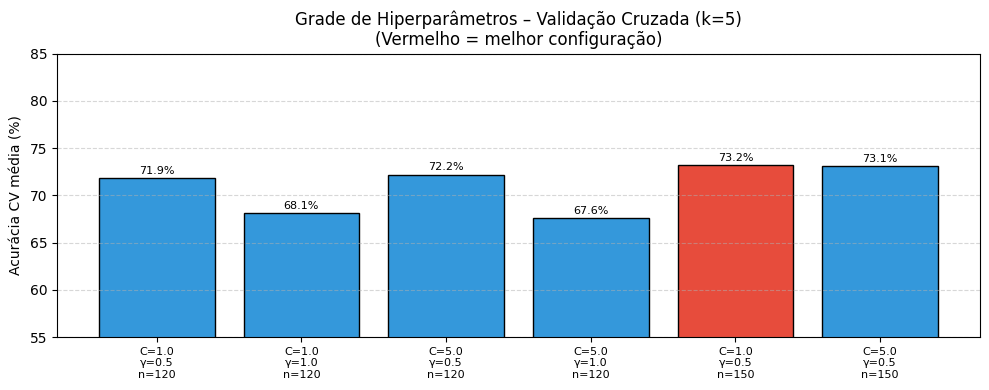

In [14]:
labels_cv = [f'C={r[0]}\nγ={r[1]}\nn={r[2]}' for r in resultados_cv]
accs_cv   = [r[4] * 100 for r in resultados_cv]
cores_cv  = ['#e74c3c' if r[4] == melhor_acc_cv else '#3498db'
             for r in resultados_cv]

plt.figure(figsize=(10, 4))
barras = plt.bar(range(len(labels_cv)), accs_cv, color=cores_cv, edgecolor='black')
plt.xticks(range(len(labels_cv)), labels_cv, fontsize=8)
plt.ylim(55, 85)
plt.ylabel('Acurácia CV média (%)')
plt.title('Grade de Hiperparâmetros – Validação Cruzada (k=5)\n'
          '(Vermelho = melhor configuração)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for barra, acc in zip(barras, accs_cv):
    plt.annotate(f'{acc:.1f}%',
                 xy=(barra.get_x() + barra.get_width()/2, acc),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', fontsize=8)
plt.tight_layout()
plt.show()


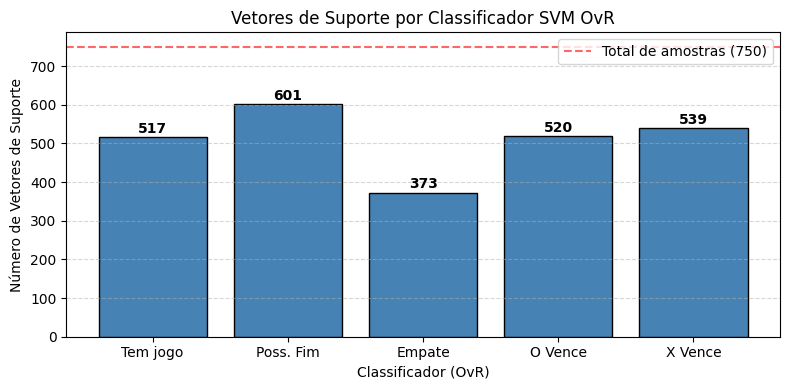

Total amostras de treino sub: 750
  Tem jogo              : 517 SVs (68.9% do treino)
  Possibilidade_fim     : 601 SVs (80.1% do treino)
  Empate                : 373 SVs (49.7% do treino)
  Fim_O_Vence           : 520 SVs (69.3% do treino)
  Fim_X_Vence           : 539 SVs (71.9% do treino)


In [15]:
n_sv_por_classe = [
    int((alphas > 1e-5).sum())
    for _, _, alphas, _ in classificadores
]

plt.figure(figsize=(8, 4))
barras_sv = plt.bar(NOMES_CURTOS, n_sv_por_classe,
                    color='steelblue', edgecolor='black')
plt.axhline(y=len(X_sub), color='red', linestyle='--', alpha=0.6,
            label=f'Total de amostras ({len(X_sub)})')
plt.ylabel('Número de Vetores de Suporte')
plt.xlabel('Classificador (OvR)')
plt.title('Vetores de Suporte por Classificador SVM OvR')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
for barra, n in zip(barras_sv, n_sv_por_classe):
    plt.annotate(str(n),
                 xy=(barra.get_x() + barra.get_width()/2, n),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total amostras de treino sub: {len(X_sub)}')
for i, (nome, n) in enumerate(zip(LABEL_NAMES, n_sv_por_classe)):
    pct = n / len(X_sub) * 100
    print(f'  {nome:22s}: {n:3d} SVs ({pct:.1f}% do treino)')


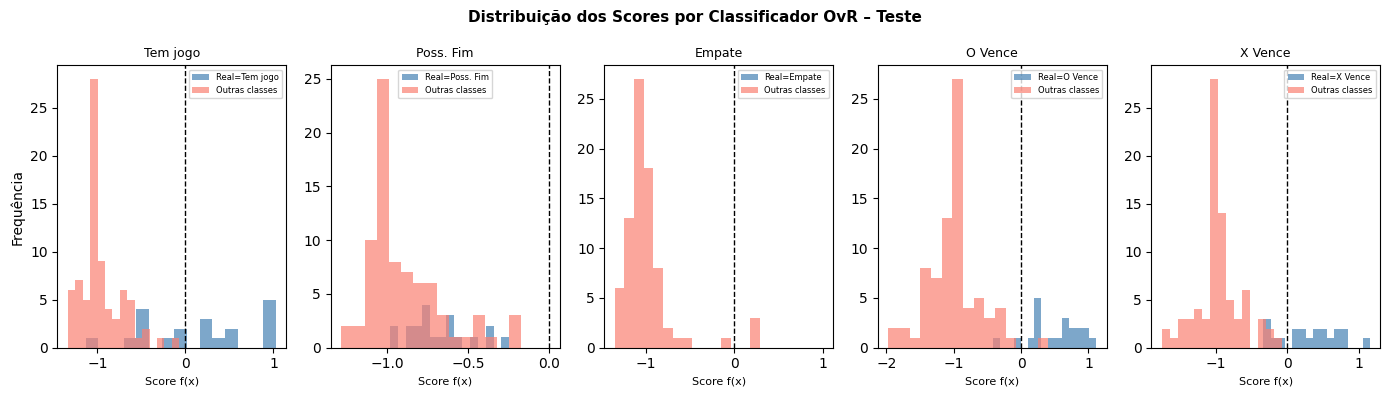

In [16]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 4), sharey=False)

for c, ax in enumerate(axes):
    sc_c    = scores_teste[c]          # scores do classificador c no teste
    is_pos  = (y_teste == c)           # amostras que realmente são classe c
    is_neg  = ~is_pos

    ax.hist(sc_c[is_pos],  bins=15, alpha=0.7, color='steelblue',
            label=f'Real={NOMES_CURTOS[c]}')
    ax.hist(sc_c[is_neg],  bins=15, alpha=0.7, color='salmon',
            label='Outras classes')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.set_title(NOMES_CURTOS[c], fontsize=9)
    ax.set_xlabel('Score f(x)', fontsize=8)
    if c == 0: ax.set_ylabel('Frequência')
    ax.legend(fontsize=6)

fig.suptitle('Distribuição dos Scores por Classificador OvR – Teste',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


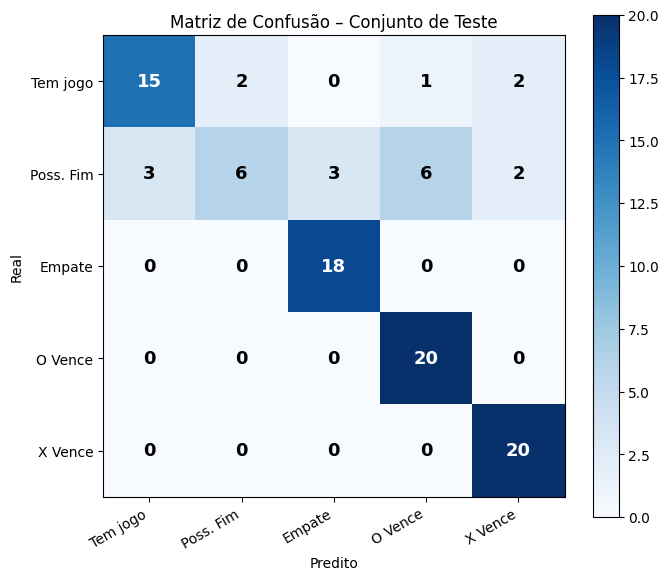

Matriz de confusão (linhas=real, colunas=predito):
[[15  2  0  1  2]
 [ 3  6  3  6  2]
 [ 0  0 18  0  0]
 [ 0  0  0 20  0]
 [ 0  0  0  0 20]]


In [17]:
matriz_conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for real, prev in zip(y_teste, pred_teste):
    matriz_conf[real][prev] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_conf, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(NOMES_CURTOS, rotation=30, ha='right')
ax.set_yticklabels(NOMES_CURTOS)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão – Conjunto de Teste')

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        cor = 'white' if matriz_conf[i,j] > matriz_conf.max()/2 else 'black'
        ax.text(j, i, str(matriz_conf[i,j]),
                ha='center', va='center', color=cor,
                fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('Matriz de confusão (linhas=real, colunas=predito):')
print(matriz_conf)


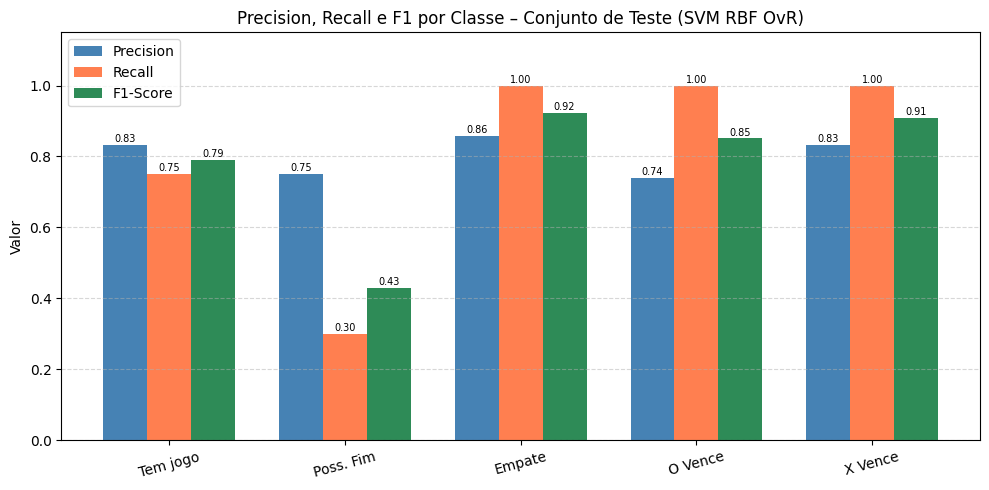

In [18]:
x_pos   = np.arange(N_CLASSES)
largura = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos - largura, prec_te, largura, label='Precision', color='steelblue')
b2 = ax.bar(x_pos,           rec_te,  largura, label='Recall',    color='coral')
b3 = ax.bar(x_pos + largura, f1_te,   largura, label='F1-Score',  color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(NOMES_CURTOS, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.set_title('Precision, Recall e F1 por Classe – Conjunto de Teste (SVM RBF OvR)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for barras in [b1, b2, b3]:
    for barra in barras:
        h = barra.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(barra.get_x() + barra.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', fontsize=7)
plt.tight_layout()
plt.show()
